In [4]:
import polaris as po
import pandas as pd
import seaborn as sns

from egfr_binder_expression import DATA_DIR
from egfr_binder_expression.dataset import get_data

%load_ext autoreload
%autoreload 2

In [5]:
df = get_data()

⠇ Fetching artifact... 

2024-10-05 15:39:44.177 | INFO     | polaris._artifact:_validate_version:66 - The version of Polaris that was used to create the artifact (0.8.7.dev1+g23fd61e.d20240926) is different from the currently installed version of Polaris (0.8.6).
2024-10-05 15:39:44.180 | INFO     | polaris.mixins._checksum:verify_checksum:65 - To verify the checksum, we need to recompute it. This can be slow for large datasets.


✅ SUCCESS: Fetched artifact.
 


/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/yaspin/core.py:239: UserWarning: color, on_color and attrs are not supported when running in jupyter
  self._color = self._set_color(value) if value else value


In [91]:
expression = pd.read_csv(DATA_DIR / 'scraped_egfr_binder_expression.csv')
expression['expression'] = expression['expression'].fillna('None')
expanded_row = expression['designer'].isna()
individuals = expression.loc[expanded_row, :]
individuals = individuals.loc[1:, :]
individuals['replicate'] = individuals.loc[expanded_row, 'design_name'].apply( lambda x: x.split(' #')[1])
individuals['design_name'] = individuals.loc[expanded_row, 'design_name'].apply( lambda x: x.split(' #')[0])

In [93]:
clean_exp = individuals.rename(
    columns={
        'propagated_designer': 'username',
        'replicate': 'replicate',
        'design_name': 'name',
        }
    ).loc[:, ['name', 'replicate', 'expression']]


In [94]:
clean_exp['replicate'] = clean_exp['replicate'].astype(int)

In [95]:
mdf = df.drop(columns=['expression']).merge(clean_exp, on=['name', 'replicate',], how='outer')


In [96]:
mdf.loc[:1, 'expression'] = 'Low'

/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 9.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 5.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='length', ylabel='expression'>

/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 16.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 15.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


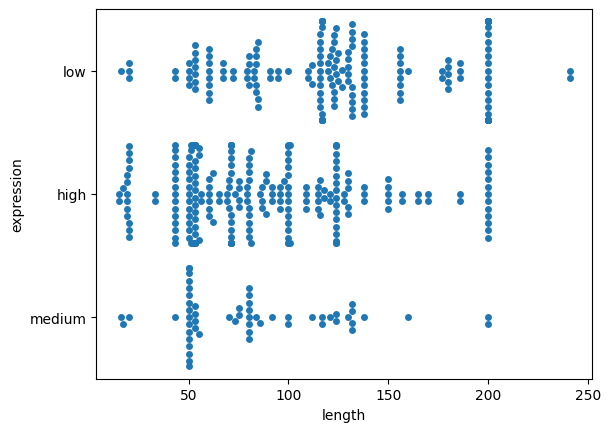

In [99]:
sns.swarmplot(df, x='length', y='expression')

/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 16.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='length', ylabel='expression'>

/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 25.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 21.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


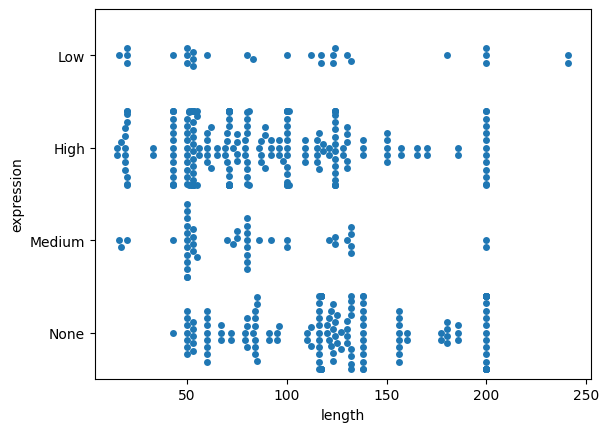

In [98]:

sns.swarmplot(mdf, x='length', y='expression')


In [2]:
from transformers import AutoTokenizer, EsmForSequenceClassification, EsmConfig
from transformers import TrainingArguments, Trainer
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from datasets import Dataset, DatasetDict
from transformers import DataCollatorWithPadding
import wandb

ModuleNotFoundError: No module named 'wandb'

In [4]:


# model_name = "facebook/esm2_t33_650M_UR50D"
model_name = "facebook/esm2_t30_150M_UR50D"

# model_name = "facebook/esm2_t6_8M_UR50D"

# Load the configuration
config = EsmConfig.from_pretrained(model_name, num_labels=3)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmForSequenceClassification.from_pretrained(model_name, config=config)


/home/naka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:

lora_config = LoraConfig(
    r=4,  # rank of the update matrices
    lora_alpha=16,  # scaling factor
    target_modules=["query", "key", "value"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_CLS,
    init_lora_weights=True,  # Initialize LoRA weights
)

# Apply LORA to the model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 872,963 || all params: 149,670,367 || trainable%: 0.5833


In [17]:
df['expression']

0         low
1         low
2      medium
3      medium
4      medium
        ...  
456       low
457       low
458       low
459      high
460      high
Name: expression, Length: 461, dtype: object

In [6]:



X = df['sequence'].tolist()
y = df['expression'].tolist()

# Encode the labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


In [7]:

# Convert your data to datasets
train_dataset = Dataset.from_dict({
    'sequence': X_train,
    'label': y_train
})
test_dataset = Dataset.from_dict({
    'sequence': X_test,
    'label': y_test
})

# Combine into a DatasetDict
dataset = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

# Tokenization function
def tokenize_function(examples):
    return tokenizer(examples['sequence'], truncation=True, max_length=512, padding='max_length')

# Apply tokenization to the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Set the format of the datasets to PyTorch
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])


Map: 100%|██████████| 93/93 [00:00<00:00, 8519.61 examples/s]


In [8]:

# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Create DataLoaders
batch_size = 1
train_dataloader = torch.utils.data.DataLoader(
    tokenized_datasets['train'], 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=data_collator
)
test_dataloader = torch.utils.data.DataLoader(
    tokenized_datasets['test'], 
    batch_size=batch_size, 
    collate_fn=data_collator
)

# Example of how to use the DataLoader
for batch in train_dataloader:
    print(batch.keys())
    print(f"Input IDs shape: {batch['input_ids'].shape}")
    print(f"Attention mask shape: {batch['attention_mask'].shape}")
    print(f"Labels shape: {batch['labels'].shape}")
    break

dict_keys(['input_ids', 'attention_mask', 'labels'])
Input IDs shape: torch.Size([1, 512])
Attention mask shape: torch.Size([1, 512])
Labels shape: torch.Size([1])


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
    acc = accuracy_score(labels, preds)
    
    # Add confusion matrix
    cm = confusion_matrix(labels, preds)
    
    # Add per-class metrics
    class_report = classification_report(labels, preds, output_dict=True, zero_division=0)
    
    # Check prediction distribution
    unique, counts = np.unique(preds, return_counts=True)
    pred_distribution = dict(zip(unique.tolist(), counts.tolist()))  # Convert to regular Python types
    
    return {
        'accuracy': float(acc),
        'f1': float(f1),
        'precision': float(precision),
        'recall': float(recall),
        # 'confusion_matrix': cm.tolist(),
        # 'class_report': {k: {k2: float(v2) for k2, v2 in v.items() if isinstance(v2, (int, float))} 
        #                  for k, v in class_report.items() if isinstance(v, dict)},
        # 'prediction_distribution': pred_distribution
    }


with wandb.init(project="egfr_binder_expression"):
        
    training_args = TrainingArguments(
        output_dir="./results",
        num_train_epochs=30,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        warmup_steps=10,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=10,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        # Add wandb project name
        report_to="wandb",
        run_name="egfr_binder_expression",
    )

    # Create Trainer instance
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        # Add compute_metrics function
        compute_metrics=compute_metrics,
    )

    # Start training
    trainer.train()

In [ ]:
# After training, let's analyze the results
eval_results = trainer.evaluate()
print(eval_results)

# Check class distribution in the training set
train_labels = tokenized_datasets['train']['label']
unique, counts = np.unique(train_labels, return_counts=True)
print("Training set class distribution:", dict(zip(unique, counts)))

In [15]:
batch = tokenized_datasets['train'][0:4]

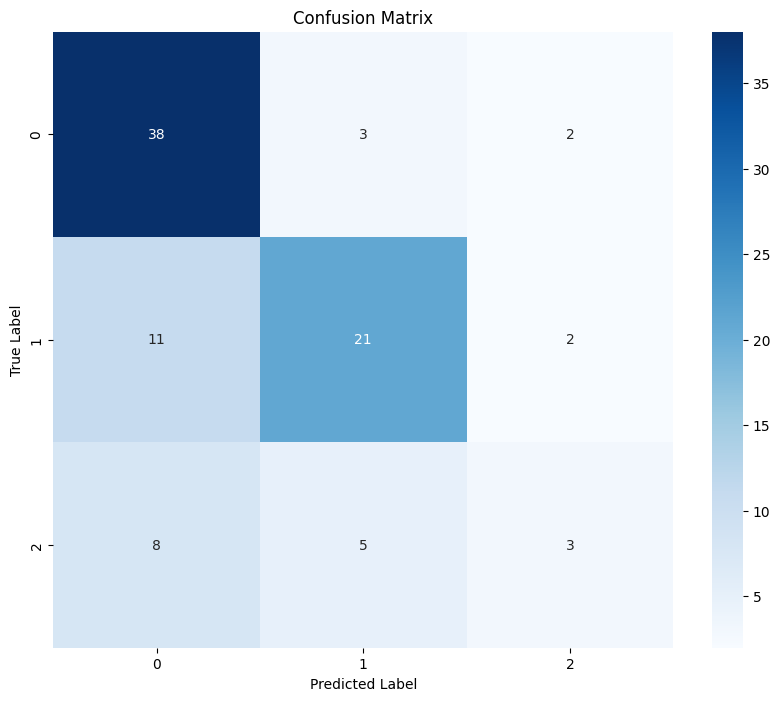

              precision    recall  f1-score   support

           0       0.67      0.88      0.76        43
           1       0.72      0.62      0.67        34
           2       0.43      0.19      0.26        16

    accuracy                           0.67        93
   macro avg       0.61      0.56      0.56        93
weighted avg       0.65      0.67      0.64        93

Prediction distribution: {0: 57, 1: 29, 2: 7}
True label distribution: {0: 43, 1: 34, 2: 16}


test/accuracy,▁
test/f1,▁
test/loss,▁
test/precision,▁
test/recall,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
test/accuracy,0.66667
test/f1,0.64001
test/loss,0.86025


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

with wandb.init(project="egfr_binder_expression"):
    # Get predictions
    trainer.model.eval()
    predictions = trainer.predict(tokenized_datasets['test'])

    # Compute confusion matrix
    y_true = predictions.label_ids
    y_pred = predictions.predictions.argmax(-1)
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Print classification report
    from sklearn.metrics import classification_report
    print(classification_report(y_true, y_pred))

    # Show prediction distribution
    unique, counts = np.unique(y_pred, return_counts=True)
    print("Prediction distribution:", dict(zip(unique, counts)))

    # Show true label distribution
    unique, counts = np.unique(y_true, return_counts=True)
    print("True label distribution:", dict(zip(unique, counts)))

In [11]:
model = model.to(device)